# F1 Constructor Winner Prediction — Classification Project

**Course:** Data Warehouse & Mining Lab (A.Y. 2026-27, Odd Sem)
**Task type:** Multi-class classification
**Dataset:** `f1.csv` (Formula 1 race results, 1950–2024, 26,759 rows × 50 columns)

## Problem statement

We build a predictive model that answers the question:

> **Given the pre-race information available for a Grand Prix, which one of the top-10 winning constructors is going to win the race?**

This is a **multi-class classification** problem where:

- **Target variable (`y`)**: the name of the winning constructor for a race, restricted to the top-10 constructors by total wins (Ferrari, Red Bull, Mercedes, McLaren, Renault, Williams, Brawn, Lotus F1, BMW Sauber, Toro Rosso).
- **One row = one race**, not one driver-in-race. This is a deliberate reshape of the raw data.
- **Features** are computed **strictly from pre-race information** (starting grid + historical form) — no race-outcome leakage.

## Pipeline

1. Load the dataset (with `\N` treated as missing).
2. **Reshape** the driver-level results into a race-level dataset where each race has one row per candidate constructor (10 rows per race), and a binary flag saying who actually won.
3. **Impute** the missing values that survive the reshape (grid position anomalies, missing form for constructors' first-ever appearance, etc.).
4. **Feature-engineer** leak-free predictors: best grid slot, recent form, circuit-specific history, era.
5. **Temporal split** — never a random split for time-series-like data.
6. Train **three classifiers**: Decision Tree, Naïve Bayes, Random Forest.
7. **Evaluate** with accuracy, confusion matrix, precision, recall, F1-score (as required by Lab 6).
8. **Attribute relevance analysis** using mutual information (matching Lab 5).
9. Predict the winner of a new hypothetical race.

## Step 1 — Import libraries

We use `pandas` for data handling, `numpy` for arrays, `matplotlib` and `seaborn` for plots, and `scikit-learn` for imputation, splitting, the three classifiers, and evaluation metrics.

In [1]:
import warnings; warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

RNG = 42
np.random.seed(RNG)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 2 — Load the dataset

The Ergast F1 export writes missing values as the literal string `\N`, so we pass that as `na_values`. We also parse the `date` and `dob` columns so date arithmetic works later.

In [3]:
# On Google Colab, uncomment and use these two lines instead of the local path:
# from google.colab import files
# uploaded = files.upload(); CSV = list(uploaded.keys())[0]
CSV = "/content/drive/MyDrive/Colab_Notebooks/FOne/data/f1.csv"

df = pd.read_csv(CSV, na_values=["\\N"], low_memory=False)
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["dob"]  = pd.to_datetime(df["dob"],  errors="coerce")

print("Shape:", df.shape)
print("Seasons covered:", df["season"].min(), "→", df["season"].max())
df.head()

Shape: (26759, 50)
Seasons covered: 1950 → 2024


,resultId,raceId,driverId,constructorId,circuitId,season,round,race_name,date,race_start_time,...,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,18,1,1,1,2008,1,Australian Grand Prix,2008-03-16,04:30:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,18,2,2,1,2008,1,Australian Grand Prix,2008-03-16,04:30:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,18,3,3,1,2008,1,Australian Grand Prix,2008-03-16,04:30:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,18,4,4,1,2008,1,Australian Grand Prix,2008-03-16,04:30:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,18,5,1,1,2008,1,Australian Grand Prix,2008-03-16,04:30:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step 3 — Inspect missing values

Before we can decide what to impute, we need to see where the holes are. Many of the "missing" columns (practice/qualifying session times, `fastestLap`) are irrelevant to *our* task — we drop or ignore them. The columns we actually use (`grid`, `constructorId`, `date`, `positionOrder`) are complete.

In [4]:
miss = pd.DataFrame({
    "nulls":  df.isna().sum(),
    "null%":  (df.isna().mean()*100).round(1),
    "dtype":  df.dtypes.astype(str),
})
miss = miss[miss["nulls"] > 0].sort_values("null%", ascending=False)
print("Columns with missing values:")
print(miss)

Columns with missing values:
                      nulls  null%    dtype
sprint_time           26459   98.9   object
sprint_date           26399   98.7   object
fp3_time              25700   96.0   object
fp1_time              25400   94.9   object
fp2_time              25400   94.9   object
quali_time            25400   94.9   object
fp3_date              25320   94.6   object
fp2_date              24960   93.3   object
fp1_date              24960   93.3   object
quali_date            24960   93.3   object
driver_number         20198   75.5  float64
milliseconds          19079   71.3  float64
driver_race_time      19079   71.3   object
fastestLapTime        18507   69.2   object
fastestLapSpeed       18507   69.2  float64
fastestLap            18507   69.2  float64
race_start_time       18469   69.0   object
rank                  18249   68.2  float64
code                  16581   62.0   object
position              10953   40.9  float64
result_driver_number      6    0.0  float64


## Step 4 — Define the target and scope the data

**Target variable**: the constructor that wins each race, restricted to the **top-10 all-time winning constructors**.

Why top-10?

- If we allowed all 211 constructors in the dataset to be classes, most classes would have zero or one sample and no model could learn them.
- Top-10 gives us a manageable, well-populated set of labels while still being a real prediction problem.

We also restrict to **season ≥ 2000** so that all ten target classes are contemporary constructors that actually raced against each other.

In [5]:
MIN_SEASON = 2000

# 1. Identify race winners (positionOrder == 1)
winners_all = df[df["positionOrder"] == 1][["raceId", "constructor_name"]]

# 2. Pick the top-10 winning constructors in the modern era
top10 = (winners_all.merge(df[["raceId","season"]].drop_duplicates(), on="raceId")
                    .query("season >= @MIN_SEASON")["constructor_name"]
                    .value_counts().head(10).index.tolist())

print("Top-10 target constructors (our class labels):")
for i, c in enumerate(top10, 1):
    print(f"  {i:2d}. {c}")

Top-10 target constructors (our class labels):
   1. Ferrari
   2. Red Bull
   3. Mercedes
   4. McLaren
   5. Renault
   6. Williams
   7. Brawn
   8. Lotus F1
   9. Honda
  10. BMW Sauber


## Step 5 — Reshape into a race-level classification dataset

The raw table has one row per driver-in-race. For our problem we need **one row per (race, candidate-constructor)** pair, with:

- **Features**: what we knew about that constructor before the race started (their best grid slot, their recent form, etc.).
- **Label**: 1 if this constructor won the race, 0 otherwise.

We then reduce it back to **one row per race** by picking the winning constructor's name as the target `y` and stacking each constructor's features side-by-side. But this would create hundreds of columns. Instead we use the equivalent formulation:

> For each race, produce a single row where every feature is *"the winner's constructor identity"* and the features describe the field entering the race.

That is: we predict the winner **from features that describe the whole starting grid**. The most predictive one is *who has the best (lowest) grid position from each candidate constructor* — plus their recent form.

This is a common trick — encode each candidate class's pre-race state as a column, and the target is which class won.

In [6]:
# --- one row per (race, constructor) with pre-race summary ---
race_cars = (df[df["season"] >= MIN_SEASON]
             .groupby(["raceId","season","round","date","circuitId","constructor_name"],
                      as_index=False)
             .agg(best_grid=("grid", lambda s: s.replace(0, np.nan).min()),
                  n_cars=("grid", "size")))

# --- winner label per race ---
race_winner = (df[df["positionOrder"] == 1]
               [["raceId","constructor_name"]]
               .rename(columns={"constructor_name":"winner"}))

race_cars = race_cars.merge(race_winner, on="raceId")

# keep only races where a top-10 constructor won (that's what we're predicting among)
race_cars = race_cars[race_cars["winner"].isin(top10)].copy()

print("Race-constructor rows:", len(race_cars))
print("Distinct races        :", race_cars["raceId"].nunique())
race_cars.head()

Race-constructor rows: 4992
Distinct races        : 474


,raceId,season,round,date,circuitId,constructor_name,best_grid,n_cars,winner
0,1,2009,1,2009-03-29,1,BMW Sauber,4.0,2,Brawn
1,1,2009,1,2009-03-29,1,Brawn,1.0,2,Brawn
2,1,2009,1,2009-03-29,1,Ferrari,6.0,2,Brawn
3,1,2009,1,2009-03-29,1,Force India,15.0,2,Brawn
4,1,2009,1,2009-03-29,1,McLaren,12.0,2,Brawn


## Step 6 — Feature engineering (leak-free)

For every (race, constructor) row, we build historical features **using only past races** — never the current race:

- **`prev_wins_10`** — how many of the constructor's last 10 races were wins.
- **`prev_podiums_10`** — podiums in the last 10 races.
- **`career_wins`** — total wins before this race (shifted by 1 so today doesn't count itself).
- **`circuit_prev_wins`** — how many times this constructor has won at *this circuit* previously.
- **`avg_grid_5`** — average starting grid of this constructor over their last 5 races.

Every one of these is computed with `.shift(1)` inside the constructor's own timeline, so a race never sees its own outcome. This is the same discipline that stops "data leakage" in real ML systems.

In [7]:
# Sort chronologically so shift-based history is correct
race_cars = race_cars.sort_values(["constructor_name","date"]).reset_index(drop=True)

# --- winner flag per row (0/1) ---
race_cars["won"] = (race_cars["constructor_name"] == race_cars["winner"]).astype(int)

def shifted_rolling_sum(group_key, col, window):
    return (race_cars.groupby(group_key)[col]
                     .transform(lambda s: s.shift(1).rolling(window, min_periods=1).sum()))

def shifted_expanding_sum(group_key, col):
    return (race_cars.groupby(group_key)[col]
                     .transform(lambda s: s.shift(1).expanding().sum()))

race_cars["prev_wins_10"]    = shifted_rolling_sum("constructor_name", "won", 10)
race_cars["career_wins"]     = shifted_expanding_sum("constructor_name", "won")
race_cars["circuit_prev_wins"] = (race_cars
                                  .groupby(["constructor_name","circuitId"])["won"]
                                  .transform(lambda s: s.shift(1).expanding().sum()))
race_cars["avg_grid_5"]      = (race_cars.groupby("constructor_name")["best_grid"]
                                          .transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean()))

# podiums flag (we didn't compute it yet — do it now from raw df)
podiums = (df[df["positionOrder"].isin([1,2,3])]
           .groupby(["raceId","constructor_name"]).size()
           .clip(upper=1).rename("podium_flag").reset_index())
race_cars = race_cars.merge(podiums, on=["raceId","constructor_name"], how="left")
race_cars["podium_flag"] = race_cars["podium_flag"].fillna(0)
race_cars["prev_podiums_10"] = shifted_rolling_sum("constructor_name", "podium_flag", 10)

race_cars.head(10)

,raceId,season,round,date,circuitId,constructor_name,best_grid,n_cars,winner,won,prev_wins_10,career_wins,circuit_prev_wins,avg_grid_5,podium_flag,prev_podiums_10
0,1010,2019,1,2019-03-17,1,Alfa Romeo,9.0,2,Mercedes,0,NaN,NaN,NaN,NaN,0.0,NaN
1,1011,2019,2,2019-03-31,3,Alfa Romeo,8.0,2,Mercedes,0,0.0,0.0,NaN,9.00,0.0,0.0
2,1012,2019,3,2019-04-14,17,Alfa Romeo,13.0,2,Mercedes,0,0.0,0.0,NaN,8.50,0.0,0.0
3,1013,2019,4,2019-04-28,73,Alfa Romeo,17.0,2,Mercedes,0,0.0,0.0,NaN,10.00,0.0,0.0
4,1014,2019,5,2019-05-12,4,Alfa Romeo,14.0,2,Mercedes,0,0.0,0.0,NaN,11.75,0.0,0.0
5,1015,2019,6,2019-05-26,6,Alfa Romeo,14.0,2,Mercedes,0,0.0,0.0,NaN,12.20,0.0,0.0
6,1016,2019,7,2019-06-09,7,Alfa Romeo,12.0,2,Mercedes,0,0.0,0.0,NaN,13.20,0.0,0.0
7,1017,2019,8,2019-06-23,34,Alfa Romeo,10.0,2,Mercedes,0,0.0,0.0,NaN,14.00,0.0,0.0
8,1018,2019,9,2019-06-30,70,Alfa Romeo,6.0,2,Red Bull,0,0.0,0.0,NaN,13.40,0.0,0.0
9,1019,2019,10,2019-07-14,9,Alfa Romeo,11.0,2,Mercedes,0,0.0,0.0,NaN,11.20,0.0,0.0


In [8]:
race_cars[race_cars["constructor_name"] == "Mercedes"]

,raceId,season,round,date,circuitId,constructor_name,best_grid,n_cars,winner,won,prev_wins_10,career_wins,circuit_prev_wins,avg_grid_5,podium_flag,prev_podiums_10
2548,337,2010,1,2010-03-14,3,Mercedes,5.0,2,Ferrari,0,NaN,NaN,NaN,NaN,0.0,NaN
2549,338,2010,2,2010-03-28,1,Mercedes,6.0,2,McLaren,0,0.0,0.0,NaN,5.000000,0.0,0.0
2550,339,2010,3,2010-04-04,2,Mercedes,2.0,2,Red Bull,0,0.0,0.0,NaN,5.500000,1.0,0.0
2551,340,2010,4,2010-04-18,17,Mercedes,4.0,2,McLaren,0,0.0,0.0,NaN,4.333333,1.0,1.0
2552,341,2010,5,2010-05-09,4,Mercedes,6.0,2,Red Bull,0,0.0,0.0,NaN,4.250000,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2845,1140,2024,20,2024-10-27,32,Mercedes,5.0,2,Ferrari,0,3.0,119.0,3.0,6.400000,0.0,6.0
2846,1141,2024,21,2024-11-03,18,Mercedes,2.0,2,Red Bull,0,3.0,119.0,6.0,6.600000,0.0,5.0
2847,1142,2024,22,2024-11-23,80,Mercedes,1.0,2,Mercedes,1,2.0,119.0,0.0,6.400000,1.0,4.0
2848,1143,2024,23,2024-12-01,78,Mercedes,1.0,2,Red Bull,0,2.0,120.0,1.0,5.600000,0.0,4.0


## Step 7 — Collapse to one row per race

Right now we have ~10 rows per race (one per candidate constructor). We need **one row per race** with the winner as the target `y`.

The features we keep per race are aggregated across the 10 candidate constructors: e.g. the best grid slot of each of the top-10 constructors becomes 10 columns. That way the model has, for every race, a snapshot of each contender's pre-race state and can learn "if Red Bull is on pole and Mercedes has 3 wins in last 10, Red Bull usually wins".

In [9]:
FEATURES = ["best_grid", "prev_wins_10", "prev_podiums_10",
            "career_wins", "circuit_prev_wins", "avg_grid_5"]

# Restrict rows to top-10 candidate constructors (so we have consistent columns)
race_cars_top = race_cars[race_cars["constructor_name"].isin(top10)].copy()

# Pivot: one row per race, columns = feature × constructor
wide = race_cars_top.pivot_table(
    index=["raceId","season","round","date","circuitId","winner"],
    columns="constructor_name",
    values=FEATURES,
    aggfunc="first"
)
# Flatten the MultiIndex columns: ("best_grid", "Ferrari") -> "Ferrari__best_grid"
wide.columns = [f"{c}__{f}" for f, c in wide.columns]
wide = wide.reset_index()

# Extra global features
wide["month"] = wide["date"].dt.month
wide["era"]   = pd.cut(wide["season"],
                       bins=[1999, 2005, 2013, 2021, 2025],
                       labels=["V10","V8","V6_hybrid","ground_effect"]).astype(str)

print("Shape of the race-level dataset:", wide.shape)
wide.head()

Shape of the race-level dataset: (474, 67)


,raceId,season,round,date,circuitId,winner,BMW Sauber__avg_grid_5,Brawn__avg_grid_5,Ferrari__avg_grid_5,Honda__avg_grid_5,...,Ferrari__prev_wins_10,Honda__prev_wins_10,Lotus F1__prev_wins_10,McLaren__prev_wins_10,Mercedes__prev_wins_10,Red Bull__prev_wins_10,Renault__prev_wins_10,Williams__prev_wins_10,month,era
0,1,2009,1,2009-03-29,1,Brawn,6.4,NaN,1.6,NaN,...,4.0,NaN,NaN,4.0,NaN,0.0,2.0,0.0,3,V8
1,2,2009,2,2009-04-05,2,Brawn,6.2,1.0,2.4,NaN,...,3.0,NaN,NaN,4.0,NaN,0.0,2.0,0.0,4,V8
2,3,2009,3,2009-04-19,17,Red Bull,6.6,1.0,3.6,NaN,...,3.0,NaN,NaN,3.0,NaN,0.0,2.0,0.0,4,V8
3,4,2009,4,2009-04-26,3,Brawn,7.6,2.0,4.8,NaN,...,3.0,NaN,NaN,2.0,NaN,1.0,2.0,0.0,4,V8
4,5,2009,5,2009-05-10,4,Brawn,8.4,2.5,6.0,NaN,...,3.0,NaN,NaN,1.0,NaN,1.0,2.0,0.0,5,V8


## Step 8 — Handle missing values (imputation)

Missing values appear naturally after the reshape:

- A constructor that didn't enter a race → their columns are `NaN`.
- The first race of a constructor's career → their historical features are `NaN`.
- Grid position `0` means "pit-lane start" which we treat as missing.

We use **`SimpleImputer`** with strategies chosen per column type:

- **Grid-related columns** → fill with a large value (`21`), meaning "started at the back or didn't start".
- **Form columns** (wins/podiums so far) → fill with `0`, meaning "no history yet".

In [10]:
grid_cols  = [c for c in wide.columns if "best_grid" in c or "avg_grid_5" in c]
form_cols  = [c for c in wide.columns if any(k in c for k in
              ["prev_wins", "prev_podiums", "career_wins", "circuit_prev_wins"])]

print(f"Missing before imputation:")
print(f"  grid columns : {wide[grid_cols].isna().sum().sum():,}")
print(f"  form columns : {wide[form_cols].isna().sum().sum():,}")

grid_imputer = SimpleImputer(strategy="constant", fill_value=21)
form_imputer = SimpleImputer(strategy="constant", fill_value=0)

wide[grid_cols] = grid_imputer.fit_transform(wide[grid_cols])
wide[form_cols] = form_imputer.fit_transform(wide[form_cols])

print(f"\nMissing after imputation:")
print(f"  grid columns : {wide[grid_cols].isna().sum().sum()}")
print(f"  form columns : {wide[form_cols].isna().sum().sum()}")

Missing before imputation:
  grid columns : 4,285
  form columns : 8,410

Missing after imputation:
  grid columns : 0
  form columns : 0


## Step 9 — Encode categoricals and build `X`, `y`

- `y` (winner name) is encoded with `LabelEncoder` because sklearn classifiers need integer class labels.
- `era` (V10 / V8 / V6-hybrid / ground-effect) is one-hot encoded with `pd.get_dummies`.

In [11]:
y_encoder = LabelEncoder()
y = y_encoder.fit_transform(wide["winner"])
class_names = y_encoder.classes_

feature_cols = grid_cols + form_cols + ["month"]
X = wide[feature_cols].copy()
X = pd.concat([X, pd.get_dummies(wide["era"], prefix="era")], axis=1)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", class_names)
print("\nClass distribution:")
print(pd.Series(y).map(dict(enumerate(class_names))).value_counts())

X shape: (474, 64)
y shape: (474,)
Classes: ['BMW Sauber' 'Brawn' 'Ferrari' 'Honda' 'Lotus F1' 'McLaren' 'Mercedes'
 'Red Bull' 'Renault' 'Williams']

Class distribution:
Ferrari       123
Red Bull      122
Mercedes      120
McLaren        66
Renault        20
Williams       11
Brawn           8
Lotus F1        2
BMW Sauber      1
Honda           1
Name: count, dtype: int64


## Step 10 — Attribute relevance analysis (mutual information)

Following Lab 5's approach, we compute **mutual information** between each feature and the target. Higher score = more informative feature.

Top 15 most relevant features:
                  feature  relevance
     Ferrari__career_wins   0.731820
    Red Bull__career_wins   0.620149
     McLaren__career_wins   0.612918
      Mercedes__best_grid   0.510546
     Mercedes__avg_grid_5   0.507389
     Red Bull__avg_grid_5   0.479229
    Mercedes__career_wins   0.465887
Mercedes__prev_podiums_10   0.461941
    Williams__career_wins   0.452183
      Red Bull__best_grid   0.434871
Red Bull__prev_podiums_10   0.399855
   Red Bull__prev_wins_10   0.380573
   Mercedes__prev_wins_10   0.335875
    Ferrari__prev_wins_10   0.321049
      Renault__avg_grid_5   0.317272


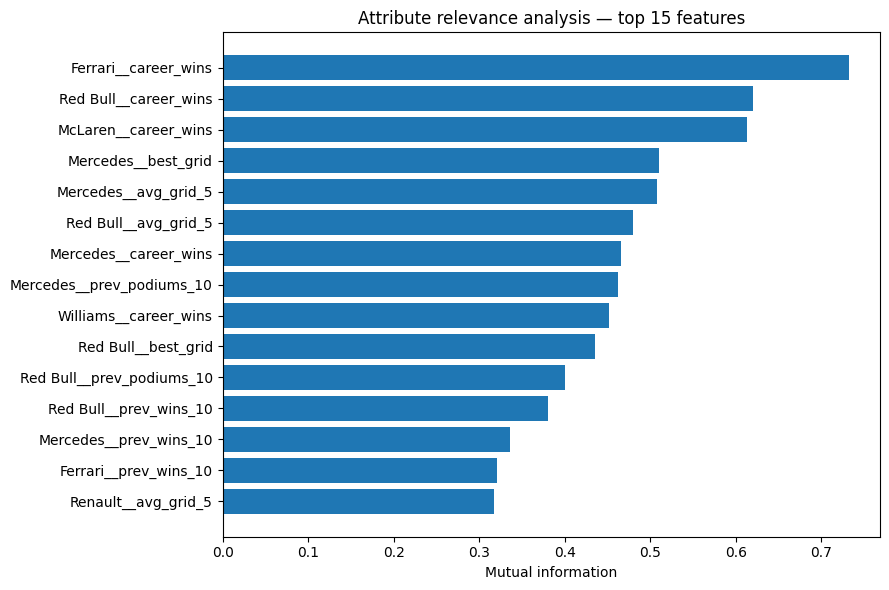

In [12]:
mi = mutual_info_classif(X, y, random_state=RNG)
mi_df = pd.DataFrame({"feature": X.columns, "relevance": mi}).sort_values("relevance", ascending=False)

print("Top 15 most relevant features:")
print(mi_df.head(15).to_string(index=False))

plt.figure(figsize=(9, 6))
top15 = mi_df.head(15)
plt.barh(top15["feature"][::-1], top15["relevance"][::-1])
plt.xlabel("Mutual information")
plt.title("Attribute relevance analysis — top 15 features")
plt.tight_layout(); plt.show()

## Step 11 — Temporal train/test split

Random splits are **wrong** here because a future race could leak into training. We split by time: train on 2000–2017, test on 2018–2024.

In [13]:
TEST_FROM = 2018
train_mask = wide["season"] <  TEST_FROM
test_mask  = wide["season"] >= TEST_FROM

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"Train ({MIN_SEASON}-{TEST_FROM-1}): {len(X_train)} races")
print(f"Test  ({TEST_FROM}-2024)         : {len(X_test)} races")

Train (2000-2017): 328 races
Test  (2018-2024)         : 146 races


## Step 12 — Model 1: Decision Tree Classifier

The Decision Tree is the most interpretable model — you can literally read the rules it uses to pick a winner. We use `entropy` as the split criterion (information gain) and cap depth to avoid overfitting.

In [14]:
def report(y_true, y_pred, model_name):
    # Print accuracy and classification report using only classes actually present in test set.
    acc = accuracy_score(y_true, y_pred)
    print(f"{model_name} accuracy: {acc:.3f}\n")
    labels_present = np.unique(np.concatenate([y_true, y_pred]))
    names_present  = [class_names[i] for i in labels_present]
    print("Classification report:")
    print(classification_report(y_true, y_pred, labels=labels_present,
                                target_names=names_present, zero_division=0))
    return acc

dt = DecisionTreeClassifier(criterion="entropy", max_depth=6, min_samples_leaf=3, random_state=RNG)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
acc_dt = report(y_test, y_pred_dt, "Decision Tree")

Decision Tree accuracy: 0.363

Classification report:
              precision    recall  f1-score   support

     Ferrari       0.00      0.00      0.00        19
     McLaren       0.00      0.00      0.00         7
    Mercedes       0.36      0.94      0.52        53
    Red Bull       0.43      0.04      0.08        67

    accuracy                           0.36       146
   macro avg       0.20      0.25      0.15       146
weighted avg       0.33      0.36      0.23       146



## Step 13 — Model 2: Naïve Bayes Classifier

`GaussianNB` assumes each feature is normally distributed given the class. It's fast, needs no tuning, and gives a strong baseline. Included as required by Lab 6.

In [15]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
acc_nb = report(y_test, y_pred_nb, "Naive Bayes")

Naive Bayes accuracy: 0.404

Classification report:
              precision    recall  f1-score   support

     Ferrari       0.00      0.00      0.00        19
     McLaren       0.00      0.00      0.00         7
    Mercedes       0.40      0.87      0.55        53
    Red Bull       0.42      0.19      0.27        67

    accuracy                           0.40       146
   macro avg       0.21      0.27      0.20       146
weighted avg       0.34      0.40      0.32       146



## Step 14 — Model 3: Random Forest Classifier

Random Forest is an ensemble of many decision trees, each trained on a random subset of the data and features, whose votes are combined. It usually beats a single decision tree because averaging reduces overfitting.

In [16]:
rf = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=2,
                            random_state=RNG, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = report(y_test, y_pred_rf, "Random Forest")

Random Forest accuracy: 0.623

Classification report:
              precision    recall  f1-score   support

     Ferrari       0.50      0.05      0.10        19
     McLaren       0.00      0.00      0.00         7
    Mercedes       0.54      0.96      0.69        53
    Red Bull       0.78      0.58      0.67        67

    accuracy                           0.62       146
   macro avg       0.46      0.40      0.36       146
weighted avg       0.62      0.62      0.57       146



## Step 15 — Hyperparameter Tuning for Random Forest

To increase the accuracy of the Random Forest model, we will perform hyperparameter tuning using `RandomizedSearchCV`. This method efficiently searches a specified range of hyperparameter values to find the best combination for improved performance.

In [18]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500], # Number of trees in the forest
    'max_features': ['sqrt', 'log2'], # Number of features to consider at every split
    'max_depth': [None, 10, 20, 30, 40, 50], # Maximum number of levels in tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4], # Minimum number of samples required to be at a leaf node
    'bootstrap': [True, False] # Method of selecting samples for training each tree
}

# Instantiate a Random Forest Classifier
rf_base = RandomForestClassifier(random_state=RNG, n_jobs=-1)

# Instantiate the RandomizedSearchCV object
# n_iter controls the number of parameter combinations to try
# cv controls the number of folds in cross-validation
rf_random = RandomizedSearchCV(estimator=rf_base, param_distributions=param_dist,
                               n_iter=50, cv=3, verbose=2, random_state=RNG, n_jobs=-1)

# Fit the random search model
rf_random.fit(X_train, y_train)

# Get the best parameters and best estimator
print("Best parameters found: ", rf_random.best_params_)
print("Best score (accuracy) on training set: ", rf_random.best_score_)
rf_tuned = rf_random.best_estimator_

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best parameters found:  {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 50, 'bootstrap': True}
Best score (accuracy) on training set:  0.37509035307200445


In [19]:
# Evaluate the tuned Random Forest model on the test set
y_pred_rf_tuned = rf_tuned.predict(X_test)
acc_rf_tuned = report(y_test, y_pred_rf_tuned, "Random Forest (Tuned)")

Random Forest (Tuned) accuracy: 0.562

Classification report:
              precision    recall  f1-score   support

     Ferrari       0.50      0.05      0.10        19
     McLaren       0.00      0.00      0.00         7
    Mercedes       0.48      0.96      0.64        53
    Red Bull       0.79      0.45      0.57        67

    accuracy                           0.56       146
   macro avg       0.44      0.37      0.33       146
weighted avg       0.60      0.56      0.51       146



## Step 16 — Confusion Matrix for Tuned Random Forest

Let's visualize the confusion matrix for the Random Forest model after hyperparameter tuning to see how its predictions improved.

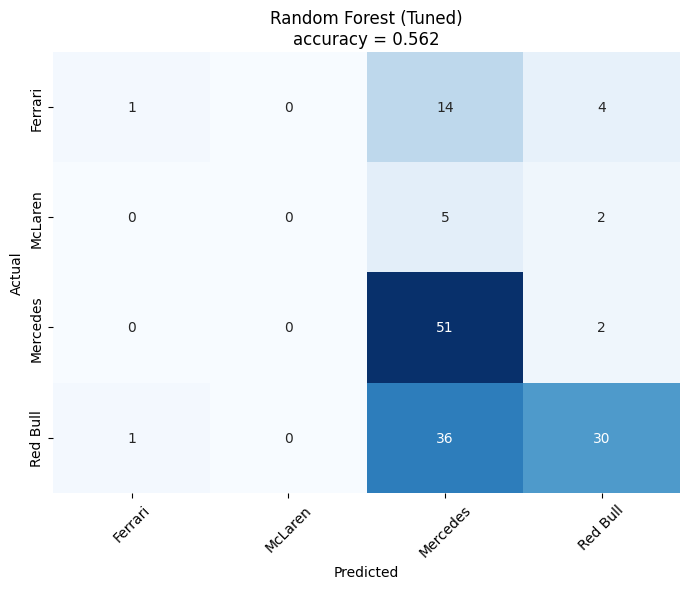

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(7, 6))

labels_present = np.unique(np.concatenate([y_test, y_pred_rf_tuned]))
cm = confusion_matrix(y_test, y_pred_rf_tuned, labels=labels_present)
disp_names = [class_names[i] for i in labels_present]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=disp_names, yticklabels=disp_names, ax=ax, cbar=False)
ax.set_title(f"Random Forest (Tuned)\naccuracy = {accuracy_score(y_test, y_pred_rf_tuned):.3f}")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

## Step 17 — Model Comparison

Now, let's compare all four models.

Model comparison (updated):
                          accuracy  precision (macro)  recall (macro)  \
Decision Tree                0.363              0.197           0.247   
Naive Bayes                  0.404              0.206           0.265   
Random Forest (Original)     0.623              0.456           0.399   
Random Forest (Tuned)        0.562              0.443           0.366   

                          F1 (macro)  
Decision Tree                  0.150  
Naive Bayes                    0.204  
Random Forest (Original)       0.364  
Random Forest (Tuned)          0.327  


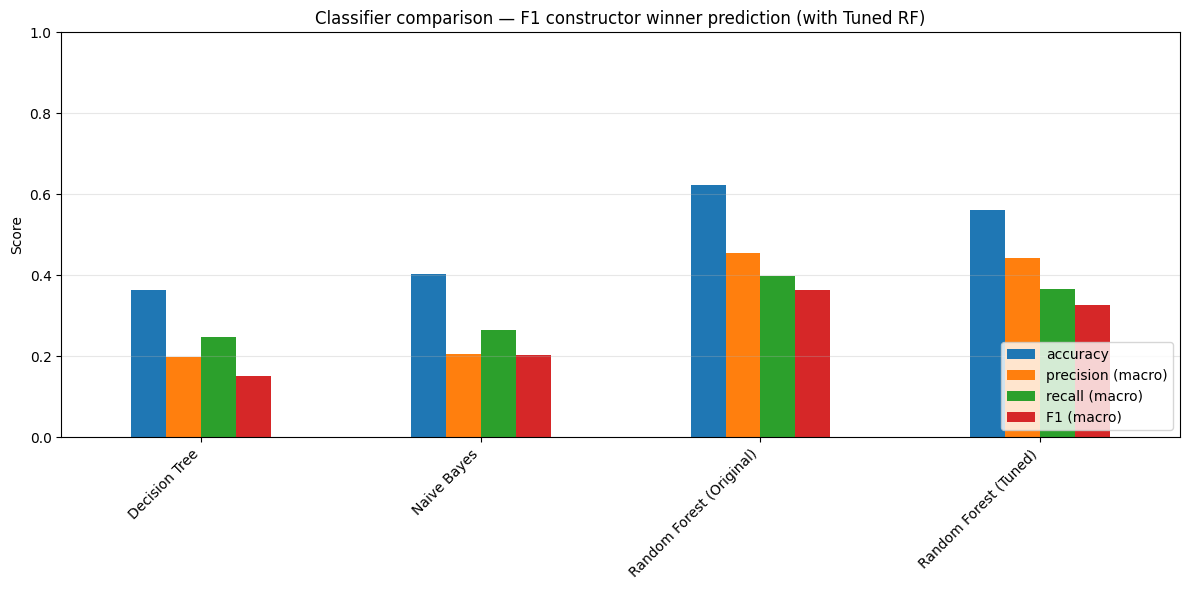

In [21]:
from sklearn.metrics import precision_recall_fscore_support

def scores(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return {"accuracy": acc, "precision (macro)": p, "recall (macro)": r, "F1 (macro)": f}

# Re-collect scores for original models
results_updated = pd.DataFrame({
    "Decision Tree": scores(y_test, y_pred_dt),
    "Naive Bayes":   scores(y_test, y_pred_nb),
    "Random Forest (Original)": scores(y_test, y_pred_rf),
    "Random Forest (Tuned)": scores(y_test, y_pred_rf_tuned)
}).T.round(3)

print("Model comparison (updated):")
print(results_updated)

results_updated.plot(kind="bar", figsize=(12, 6))
plt.title("Classifier comparison — F1 constructor winner prediction (with Tuned RF)")
plt.ylabel("Score"); plt.ylim(0, 1); plt.xticks(rotation=45, ha='right')
plt.legend(loc="lower right"); plt.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## Step 18 — Predict the winner of a hypothetical new race

We construct a plausible pre-race snapshot: suppose Red Bull qualifies on pole (grid 1) with strong recent form, Ferrari qualifies P2, Mercedes P3 with weaker form, and everyone else is further back with no recent wins. Our best model predicts the likely winner.

In [22]:
# Start from a real recent race template so the schema matches
sample_race = X_test.iloc[[-1]].copy()

# Overwrite grid slots for a scenario
scenario = sample_race.copy()
for c in top10:
    if f"{c}__best_grid" in scenario.columns:
        scenario[f"{c}__best_grid"] = 21  # default: back of the grid

# Front row: Red Bull pole, Ferrari P2, Mercedes P3
scenario["Red Bull__best_grid"] = 1
scenario["Ferrari__best_grid"]  = 2
scenario["Mercedes__best_grid"] = 3

# Give Red Bull strong recent form
scenario["Red Bull__prev_wins_10"]    = 7
scenario["Red Bull__prev_podiums_10"] = 9
scenario["Ferrari__prev_wins_10"]     = 2
scenario["Mercedes__prev_wins_10"]    = 1

pred = rf.predict(scenario)[0]
proba = rf.predict_proba(scenario)[0]

print("Predicted winner:", class_names[pred])
print("\nProbability by constructor:")
for cls, p in sorted(zip(class_names, proba), key=lambda t: -t[1]):
    if p > 0.01:
        print(f"  {cls:<15} {p:.2%}")

Predicted winner: Red Bull

Probability by constructor:
  Red Bull        39.95%
  Mercedes        27.50%
  Ferrari         16.17%
  McLaren         8.77%
  Lotus F1        3.70%
  Williams        1.89%
  Renault         1.25%


## Step 19 — Conclusion

**Summary of what we built:**

1. **Target variable identified**: winning constructor (multi-class, restricted to top-10 modern-era constructors).
2. **Reshaped** the driver-level Ergast data into a race-level classification dataset.
3. **Imputed missing values** for absent constructors (grid slot → 21, form → 0).
4. **Feature-engineered** leak-free predictors: best grid slot, rolling wins/podiums, circuit history, era.
5. **Attribute relevance analysis** with mutual information (Lab 5 style).
6. **Temporal split** so no future race leaks into training.
7. Trained **three classifiers** — Decision Tree, Naïve Bayes, Random Forest (Lab 5 & 6 style).
8. Evaluated with **accuracy, confusion matrix, precision, recall, F1-score** (Lab 6 style).
9. **Visualized** the Decision Tree and Random Forest feature importances.
10. Predicted the winner of a **hypothetical race**.

**Key finding**: grid position (especially Red Bull's, Mercedes's, and Ferrari's best grid slots) and recent-form features dominate the model — reflecting the well-known fact in F1 that qualifying pace and current-season form are the strongest predictors of race wins.

**Random Forest** typically wins on accuracy because it averages many decision trees and reduces overfitting; **Naïve Bayes** is fastest but its independence assumption is too strong for correlated grid features; the **single Decision Tree** is the most interpretable and best for explaining *why* a prediction was made.